1. Cài đặt các thư viện cần thiết


In [2]:
pip install pandas scikit-learn pyvi transformers torch tensorflow datasets tqdm joblib matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Đang tải dữ liệu Test từ Hugging Face ---
--- Đang tiền xử lý 3272 mẫu dữ liệu test... ---

--- [1/3] Đang tải & Đánh giá SVM từ neidythedev/vietnamese-restaurant-sentiment-svm ---

--- [3/3] Đang tải & Đánh giá PhoBERT từ pqthinh232/HCMUS-phobert-vietnamese-restaurant-sentiment-analysis ---


c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:722: UserWarning: Not enough free disk space to download the file. The expected file size is: 540.03 MB. The target location C:\Users\ACER\.cache\huggingface\hub\models--pqthinh232--HCMUS-phobert-vietnamese-restaurant-sentiment-analysis\blobs only has 0.00 MB free disk space.
  warnings.warn(


Lỗi tải PhoBERT: Can't load the model for 'pqthinh232/HCMUS-phobert-vietnamese-restaurant-sentiment-analysis'. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local directory with the same name. Otherwise, make sure 'pqthinh232/HCMUS-phobert-vietnamese-restaurant-sentiment-analysis' is the correct path to a directory containing a file named pytorch_model.bin.

KẾT QUẢ SO SÁNH (MAX_LENGTH=256)
Model  Accuracy  Macro F1  F1 Class 0  Time/Sample (s)
  SVM  0.824572  0.799402    0.861538         0.009349


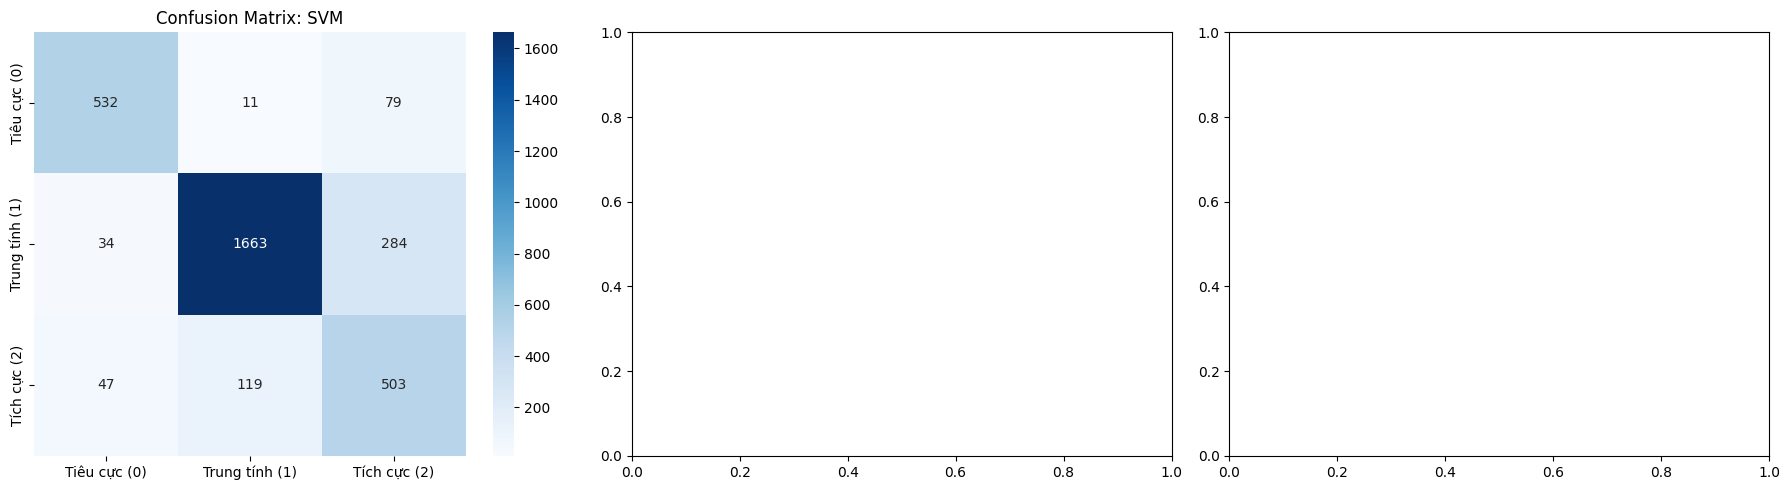

In [1]:
import pandas as pd
import numpy as np
import time
import torch
import joblib
import re
import os
import tensorflow as tf
from pyvi import ViTokenizer
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# 0. CẤU HÌNH HỆ THỐNG
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" # Ép chạy CPU để đo tốc độ công bằng
device = torch.device('cpu')
MAX_LEN = 256 

# --- THAY ĐỔI USERNAME VÀ REPO TẠI ĐÂY ---
REPO_SVM = "neidythedev/vietnamese-restaurant-sentiment-svm"
REPO_BIGRU = "user_b/bigru-sentiment-model"
REPO_PHOBERT = "pqthinh232/HCMUS-phobert-vietnamese-restaurant-sentiment-analysis"

# 1. TẢI DỮ LIỆU TEST
print("--- Đang tải dữ liệu Test từ Hugging Face ---")
dataset = load_dataset("pqthinh232/vietnamese-restaurant-review-sentiment-dataset")
df_test = pd.DataFrame(dataset['test'])

# 2. HÀM TIỀN XỬ LÝ CHUẨN HÓA (Dùng chung cho cả 3 để đảm bảo công bằng)
def preprocess_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = ViTokenizer.tokenize(text)
    words = text.split()
    return " ".join(words[:MAX_LEN]) # Truncate 256

print(f"--- Đang tiền xử lý {len(df_test)} mẫu dữ liệu test... ---")
df_test['clean_review'] = df_test['review'].apply(preprocess_text)
X_test_text = df_test['clean_review'].tolist()
y_true = df_test['label'].tolist()

results_map = {}

# ---------------------------------------------------------
# 3. ĐÁNH GIÁ MODEL 1: SVM (Từ User A)
# ---------------------------------------------------------
print(f"\n--- [1/3] Đang tải & Đánh giá SVM từ {REPO_SVM} ---")
try:
    path_svm = hf_hub_download(repo_id=REPO_SVM, filename="svm_sentiment_model.pkl")
    path_tfidf = hf_hub_download(repo_id=REPO_SVM, filename="tfidf_vectorizer.pkl")
    
    svm_model = joblib.load(path_svm)
    tfidf = joblib.load(path_tfidf)

    start = time.time()
    X_tfidf = tfidf.transform(X_test_text)
    y_pred_svm = svm_model.predict(X_tfidf)
    svm_time = (time.time() - start) / len(y_true)
    results_map['SVM'] = (y_pred_svm, svm_time)
except Exception as e: print(f"Lỗi tải SVM: {e}")



# ---------------------------------------------------------
# 5. ĐÁNH GIÁ MODEL 3: PhoBERT (Từ User C)
# ---------------------------------------------------------
print(f"\n--- [3/3] Đang tải & Đánh giá PhoBERT từ {REPO_PHOBERT} ---")
try:
    phobert_tokenizer = AutoTokenizer.from_pretrained(REPO_PHOBERT)
    phobert_model = AutoModelForSequenceClassification.from_pretrained(REPO_PHOBERT).to(device)

    y_pred_phobert = []
    start = time.time()
    phobert_model.eval()
    with torch.no_grad():
        for text in tqdm(X_test_text):
            inputs = phobert_tokenizer(text, return_tensors="pt", truncation=True, 
                                      max_length=MAX_LEN, padding='max_length').to(device)
            outputs = phobert_model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            y_pred_phobert.append(pred)
            
    phobert_time = (time.time() - start) / len(y_true)
    results_map['PhoBERT'] = (y_pred_phobert, phobert_time)
except Exception as e: print(f"Lỗi tải PhoBERT: {e}")

# ---------------------------------------------------------
# 6. TỔNG HỢP VÀ SO SÁNH KẾT QUẢ
# ---------------------------------------------------------
comparison_rows = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
target_names = ['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)']

for i, (name, (y_pred, inf_time)) in enumerate(results_map.items()):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    # F1 riêng cho lớp 0 để đánh giá khả năng bắt lỗi tiêu cực
    f1_class0 = f1_score(y_true, y_pred, labels=[0], average='macro')
    
    comparison_rows.append([name, acc, macro_f1, f1_class0, inf_time])
    
    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    axes[i].set_title(f"Confusion Matrix: {name}")

# Xuất bảng so sánh
df_final = pd.DataFrame(comparison_rows, columns=["Model", "Accuracy", "Macro F1", "F1 Class 0", "Time/Sample (s)"])
print("\n" + "="*60)
print(f"KẾT QUẢ SO SÁNH (MAX_LENGTH={MAX_LEN})")
print("="*60)
print(df_final.to_string(index=False))

plt.tight_layout()
plt.show()

model của Lợi để Lợi add vào sau

# ---------------------------------------------------------
# 4. ĐÁNH GIÁ MODEL 2: BiGRU (Từ User B)
# ---------------------------------------------------------
print(f"\n--- [2/3] Đang tải & Đánh giá BiGRU từ {REPO_BIGRU} ---")
try:
    path_bigru = hf_hub_download(repo_id=REPO_BIGRU, filename="bigru_model.h5")
    path_token = hf_hub_download(repo_id=REPO_BIGRU, filename="tokenizer.pkl")
    
    bigru_model = tf.keras.models.load_model(path_bigru)
    bigru_tokenizer = joblib.load(path_token)

    from tensorflow.keras.preprocessing.sequence import pad_sequences
    start = time.time()
    X_seq = bigru_tokenizer.texts_to_sequences(X_test_text)
    X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')
    y_prob_bigru = bigru_model.predict(X_pad, verbose=0)
    y_pred_bigru = np.argmax(y_prob_bigru, axis=1)
    bigru_time = (time.time() - start) / len(y_true)
    results_map['BiGRU'] = (y_pred_bigru, bigru_time)
except Exception as e: print(f"Lỗi tải BiGRU: {e}")